##  Problem Statement

Modern AI applications often require **automated agents** that can interact without human involvement. Traditional chatbots are limited in creativity or collaborative reasoning. The **AutoGen framework** solves this by allowing **multiple autonomous AI agents** to talk to each other and collaborate in a human-like conversation.

This example shows how to use AutoGen to:
1. Create a single chatbot that responds to a joke request.
2. Simulate a humorous conversation between **two AI agents** (Cathy and Joe), each with its own personality.

---

## Objectives

- Install and configure the **AutoGen** framework.
- Create an **autonomous chatbot agent** with GPT-4 using OpenAI API.
- Show how **two AI agents (Cathy and Joe)** can converse with each other.
- Customize system messages and temperature to define different personalities.
- Demonstrate how agents **talk autonomously without human input**.

---

## Expected Outcomes

- A working chatbot that tells a joke on request.
- A short, simulated comedy-style conversation between Cathy and Joe.
- Demonstration of how AutoGen agents can interact **without human help**.
- Clear illustration of how you can define agent **roles, tone, and behavior**.

---

In [1]:
# Installation
!pip install autogen -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Set OpenAI API Key
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [3]:
# Single Agent
from autogen import ConversableAgent

agent = ConversableAgent(
    "chatbot",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}]},
    code_execution_config=False,  # Turn off code execution, by default it is off.
    function_map=None,  # No registered functions, by default it is None.
    human_input_mode="NEVER",  # Never ask for human input.
)
reply = agent.generate_reply(messages=[{"content": "Tell me a joke.", "role": "user"}])
print(reply)

Sure, here is a joke for you:

Why don't scientists trust atoms?

Because they make up everything!


In [4]:
# Two Agent Conversation

cathy = ConversableAgent(
    "cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}],
        "temperature": 0.9,
    },
    human_input_mode="NEVER",
)

joe = ConversableAgent(
    "joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [{"model": "gpt-4", "api_key": os.environ.get("OPENAI_API_KEY")}],
        "temperature": 0.7,
    },
    human_input_mode="NEVER",
)

In [5]:
result = joe.initiate_chat(cathy, message="Cathy, tell me a joke.", max_turns=2)


joe (to cathy):

Cathy, tell me a joke.

--------------------------------------------------------------------------------
cathy (to joe):

Why don't scientists trust atoms?

Because they make up everything!

--------------------------------------------------------------------------------
joe (to cathy):

Ah, that's a good one Cathy! Alright, I've got one. Why don't we ever tell secrets on a farm?

Because the potatoes have eyes, the corn has ears, and the beans stalk!

--------------------------------------------------------------------------------
cathy (to joe):

Oh, Joe! That's a real knee-slapper. Here's another one for you. Why don't some fish play piano?

Because you can't tuna fish!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (d45f7442-ba98-4196-9210-c0b19a7f67f0): Maximum turns (2) reached


##  Problem Statement

While traditional AI chatbots can respond to users, they don’t typically hold autonomous, multi-turn conversations with each other—especially in a controlled, dynamic way with custom logic. This example uses the **AutoGen framework** to simulate a **multi-agent conversation** between two distinct AI personas, Cathy and Joe, who play the role of a comedic duo.

The goal is to showcase how to:
- Build separate agents with different personalities and tones.
- Control how many times they talk back and forth.
- Define **custom stopping conditions** (like when someone says "good bye").

---

## Objectives

- Create two AI agents (`Cathy` and `Joe`) using `ConversableAgent` from AutoGen.
- Customize their behavior using:
  - Different **temperature values** to simulate tone.
  - Distinct **system messages** to define their personalities.
- Demonstrate:
  - **Basic conversation** with limited turns.
  - **Longer multi-turn chat**.
  - **Auto-stopping chat** based on the message content.

---

## Expected Outcomes

- You will see **multiple simulations** where AI agents converse with each other.
- Each agent will behave differently based on temperature and message rules.
- A conversation will **automatically stop** when a specific condition is met (like saying "good bye").
- You will learn how to **simulate realistic and custom AI personas** with complete autonomy.

---

In [6]:
# Agent Cathy
cathy = ConversableAgent(
    name="cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.9,
    },
    human_input_mode="NEVER",
)

# Agent Joe
joe = ConversableAgent(
    name="joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.7,
    },
    human_input_mode="NEVER",
    max_consecutive_auto_reply=1, # Limit Joe to only reply once consecutively without waiting for Cathy to reply, to avoid Joe dominating the conversation.
)

# Make Joe initiate a chat with Cathy
result = joe.initiate_chat(cathy, message="Cathy, tell me a joke.")

joe (to cathy):

Cathy, tell me a joke.

--------------------------------------------------------------------------------
cathy (to joe):

Sure, here's one for you, Joe. Why don't scientists trust atoms?

Because they make up everything!

--------------------------------------------------------------------------------
joe (to cathy):

Haha, good one Cathy! Now, here's one for you. Why don't some fish play piano?

Because you can't tuna fish!

--------------------------------------------------------------------------------
cathy (to joe):

Haha, nice one, Joe! I see you have a knack for comedy as well! Let's keep the fun going!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (7dda12e2-173e-40be-a141-eea93d1e5c50): Maximum number of consecutive auto-replies reached


In [8]:
# Define Cathy first (needed for chat)
cathy = ConversableAgent(
    name="cathy",
    system_message="Your name is Cathy and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.9
    },
    human_input_mode="NEVER",
)

# Define Joe with corrected llm_config and custom termination rule
joe = ConversableAgent(
    name="joe",
    system_message="Your name is Joe and you are a part of a duo of comedians.",
    llm_config={
        "config_list": [
            {
                "model": "gpt-4",
                "api_key": os.environ.get("OPENAI_API_KEY")
            }
        ],
        "temperature": 0.7  
    },
    human_input_mode="NEVER",
    is_termination_msg=lambda msg: "good bye" in msg["content"].lower(),
)

# Start the conversation
result = joe.initiate_chat(
    cathy,
    message="Cathy, tell me a joke and then say the words GOOD BYE."
)

joe (to cathy):

Cathy, tell me a joke and then say the words GOOD BYE.

--------------------------------------------------------------------------------
cathy (to joe):

Sure, here's one for you. Why don't scientists trust atoms? Because they make up everything! GOOD BYE!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (4da56d7b-e255-4e53-a35c-4488162b580e): Termination message condition on agent 'joe' met


## Problem Statement

Most AI agents are designed to respond reactively to direct user input. But what if we want two AI agents to play an interactive game with each other and even involve a human when needed?

This example demonstrates the use of **AutoGen’s ConversableAgent** framework to simulate a **“Guess My Number” game** between two agents. One agent picks a secret number, and the other tries to guess it through feedback loops like "too high" or "too low". Additionally, a human can also jump in and interact with the system at any point.

---

## Objectives

- Create an agent (`agent_with_number`) that holds a fixed number (e.g., 53) in mind.
- Build another agent (`agent_guess_number`) whose job is to intelligently guess the number.
- Allow agents to talk to each other until the number is correctly guessed.
- Introduce a **human agent** (`human_proxy`) to play manually.
- Limit auto-replies to encourage human intervention when needed.
- Stop the game automatically once the correct number is guessed.

---

## Expected Outcomes

- A simulation of two AI agents playing a guessing game in multiple modes (fully autonomous and human-in-the-loop).
- Demonstration of:
  - Custom termination condition (`"53" in message`).
  - Dynamic turn-based logic between agents.
  - Use of `max_consecutive_auto_reply` to bring human into the loop after a limit.
- Human user can take over at any point and continue playing against the AI agent.

---

In [9]:
agent_with_number = ConversableAgent(
    "agent_with_number",
    system_message="You are playing a game of guess-my-number. You have the "
    "number 53 in your mind, and I will try to guess it. "
    "If I guess too high, say 'too high', if I guess too low, say 'too low'. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    is_termination_msg=lambda msg: "53" in msg["content"],  # terminate if the number is guessed by the other agent
    human_input_mode="NEVER",  # never ask for human input
)

agent_guess_number = ConversableAgent(
    "agent_guess_number",
    system_message="I have a number in my mind, and you will try to guess it. "
    "If I say 'too high', you should guess a lower number. If I say 'too low', "
    "you should guess a higher number. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)


result = agent_with_number.initiate_chat(
    agent_guess_number,
    message="I have a number between 1 and 100. Guess it!",
)

agent_with_number (to agent_guess_number):

I have a number between 1 and 100. Guess it!

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

50

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too low.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

75

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too high.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

70

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

Too high.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_n

In [10]:
human_proxy = ConversableAgent(
    "human_proxy",
    llm_config=False,  # no LLM used for human proxy
    human_input_mode="ALWAYS",  # always ask for human input
)

# Start a chat with the agent with number with an initial guess.
result = human_proxy.initiate_chat(
    agent_with_number,  # this is the same agent with the number as before
    message="10",
)

human_proxy (to agent_with_number):

10

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too low.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

51

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too low.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

100

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too high.

--------------------------------------------------------------------------------
human_proxy (to agent_with_number):

75

--------------------------------------------------------------------------------
agent_with_number (to human_proxy):

Too high.

------------------------------------------------------------------------------

In [11]:
agent_with_number = ConversableAgent(
    "agent_with_number",
    system_message="You are playing a game of guess-my-number. "
    "In the first game, you have the "
    "number 53 in your mind, and I will try to guess it. "
    "If I guess too high, say 'too high', if I guess too low, say 'too low'. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    max_consecutive_auto_reply=1,  # maximum number of consecutive auto-replies before asking for human input
    is_termination_msg=lambda msg: "53" in msg["content"],  # terminate if the number is guessed by the other agent
    human_input_mode="TERMINATE",  # ask for human input until the game is terminated
)

agent_guess_number = ConversableAgent(
    "agent_guess_number",
    system_message="I have a number in my mind, and you will try to guess it. "
    "If I say 'too high', you should guess a lower number. If I say 'too low', "
    "you should guess a higher number. ",
    llm_config={"config_list": [{"model": "gpt-4", "api_key": os.environ["OPENAI_API_KEY"]}]},
    human_input_mode="NEVER",
)

result = agent_with_number.initiate_chat(
    agent_guess_number,
    message="I have a number between 1 and 100. Guess it!",
)

agent_with_number (to agent_guess_number):

I have a number between 1 and 100. Guess it!

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 50?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
agent_with_number (to agent_guess_number):

Too low.

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 75?

--------------------------------------------------------------------------------
agent_with_number (to agent_guess_number):

too high

--------------------------------------------------------------------------------
agent_guess_number (to agent_with_number):

Is it 62?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
agent_with_number (to agent_guess_number):

Too high.

------------------------------------

### **Problem Statement**
In many real-world AI use cases, generating code is not enough—executing and validating it is critical. This project demonstrates how to create a code-executing AI system using **AutoGen’s `ConversableAgent` and `LocalCommandLineCodeExecutor`**. The system lets one AI agent write Python code and another safely execute it in a sandboxed local environment. This adds real execution capabilities and error handling to AI conversations, making them interactive, intelligent, and actionable.

---

### **Objectives**
- Use **AutoGen** framework to set up two agents: one to write code and another to execute it.
- Allow code execution in a safe, temporary directory using `LocalCommandLineCodeExecutor`.
- Create agents with:
  - LLM-turned-off executor agent (for safe code execution only).
  - GPT-4-powered writer agent that can generate Python code.
- Demonstrate code generation and execution:
  - A scatter plot using NumPy and Matplotlib.
  - Calculating the 14th Fibonacci number.
  - Plotting stock gains for TSLA and META using dynamic date input.

---

### **Expected Outcomes**
- The code executor agent will execute Python code safely and return output (e.g., plots, numbers).
- GPT-4 (code-writer agent) will write correct and complete code blocks based on user requests.
- A successful conversation loop between the writer and executor will simulate realistic coding scenarios.
- Files like `scatter.png` and `stock_gains.png` will be saved in a temp directory.

---

In [12]:
import tempfile
# tempfile - used to create temporary directories and files, which can be useful for storing code files generated by agents during conversations, especially when using code execution features.

from autogen import ConversableAgent
from autogen.coding import LocalCommandLineCodeExecutor
# LocalCommandLineCodeExecutor - This is a code executor that allows agents to execute code in a local command-line environment. It can be used to run code snippets generated by agents during conversations, enabling dynamic code execution and interaction.

# Create a temporary directory to store the code files.
temp_dir = tempfile.TemporaryDirectory()

# Create a local command line code executor.
executor = LocalCommandLineCodeExecutor(
    timeout=10,  # Timeout for each code execution in seconds.
    work_dir=temp_dir.name,  # Use the temporary directory to store the code files.
)

# Create an agent with code executor configuration.
code_executor_agent = ConversableAgent(
    "code_executor_agent",
    llm_config=False,  # Turn off LLM for this agent.
    code_execution_config={"executor": executor},  # Use the local command line code executor.
    human_input_mode="ALWAYS",  # Always take human input for this agent for safety.
)

In [13]:
! pip install -qqq matplotlib numpy

In [14]:
message_with_code_block = """This is a message with code block.
The code block is below:
```python
import numpy as np
import matplotlib.pyplot as plt
x = np.random.randint(0, 100, 100)
y = np.random.randint(0, 100, 100)
plt.scatter(x, y)
plt.savefig('scatter.png')
print('Scatter plot saved to scatter.png')
```
This is the end of the message.
"""

# Generate a reply for the given code.
reply = code_executor_agent.generate_reply(messages=[{"role": "user", "content": message_with_code_block}])
print(reply)


>>>>>>>> NO HUMAN INPUT RECEIVED.

>>>>>>>> USING AUTO REPLY...

>>>>>>>> EXECUTING CODE BLOCK (inferred language is python)...
exitcode: 0 (execution succeeded)
Code output: Scatter plot saved to scatter.png



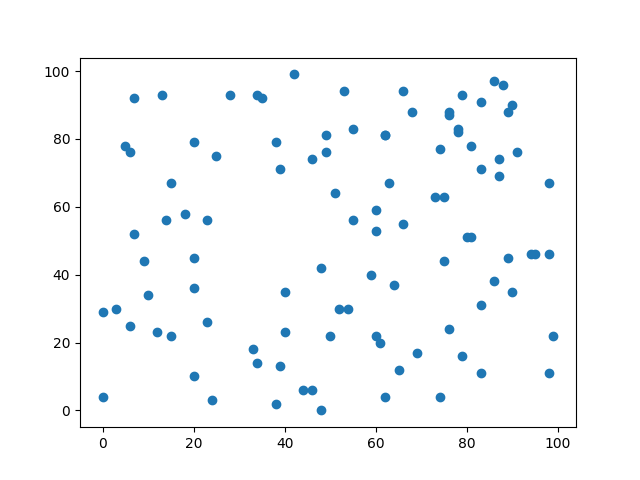

In [15]:
# Read the output file.
with open(os.path.join(temp_dir.name, "scatter.png"), "rb") as f:
    scatter_plot = f.read()
# Display the output file.
from IPython.display import Image
Image(scatter_plot)

In [16]:
import os

print(os.listdir(temp_dir.name))
# We can see the output scatter.png and the code file generated by the agent.

['tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py', 'scatter.png']


In [17]:
# Print pathb of "tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py" file, which is the code file generated by the agent to execute the code block in the message.
print(os.path.join(temp_dir.name, "tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py"))

/var/folders/5g/9xpg7d6d4114s98tv10y9rgm0000gn/T/tmp7173aqtn/tmp_code_e24bf32d4a21990fb9e4b5eb889ebe5a.py
